In [30]:
# Annotated é usado para acrescentar uma anotação ao dado
# Sequence é imutável e não pode ser alterada
from typing import TypedDict, Annotated, Sequence
# BaseMessage é o pai das outras mensagens
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import add_messages
from langchain_core.tools import tool
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

from dotenv import load_dotenv
load_dotenv()

True

In [31]:
@tool
def my_info() -> dict:
    """Retorna meu nome e minha idade"""
    return {"nome": "Lucas", "idade": 27}

tools = [my_info]

In [32]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages] # Com o add_messages não precisamos dar um append

In [33]:
llm = ChatNVIDIA(model="openai/gpt-oss-20b").bind_tools(tools)

In [34]:
def model_call(state: AgentState) -> AgentState:
    system_prompt = SystemMessage(content = "Você é um assistente que faz o máximo para responder minhas perguntas")

    response = llm.invoke([system_prompt] + state["messages"])
    return {"messages": [response]}

In [35]:
def should_continue(state: AgentState):
    messages = state["messages"]
    last_message = messages[-1]

    if not last_message.tool_calls:
        return "end"
    else:
        return "continue"

In [36]:
graph = StateGraph(AgentState)
graph.add_node("agent", model_call)

tool_node = ToolNode(tools=tools)
graph.add_node("tools", tool_node)

graph.set_entry_point("agent")

graph.add_conditional_edges(
    "agent",
    should_continue,
    {
        "continue": "tools",
        "end": END
    }
)

graph.add_edge("tools", "agent")

app = graph.compile()

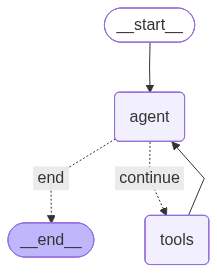

In [37]:
app

In [38]:
def print_stream(stream):
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()
query = "Quantos anos eu tenho?"
inputs = {"messages": [("user", query)]}
print_stream(app.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Quantos anos eu tenho?
================================== Ai Message ==================================
Tool Calls:
  my_info (chatcmpl-tool-b5ba508d39babaea)
 Call ID: chatcmpl-tool-b5ba508d39babaea
  Args:
================================= Tool Message =================================
Name: my_info

{"nome": "Lucas", "idade": 27}
================================== Ai Message ==================================

Você tem 27 anos.
